In [12]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

dfnc = pd.read_parquet("new_construction.parquet")
dfnc.to_csv("new_construction.csv", index = False)
dfnc.shape

(49487, 10)

In [14]:
dfnc.head()

,Region ID,Size Rank,Region,Region Type,State,Home Type,Date,Median Sale Price,Median Sale Price per Sqft,Sales Count
0,102001,0,United States,5,None,2,2018-01-31,309000.0,137.412323,33940.0
1,102001,0,United States,5,None,2,2018-02-28,309072.5,137.199173,33304.0
2,102001,0,United States,5,None,2,2018-03-31,315488.0,139.520859,42641.0
3,102001,0,United States,5,None,2,2018-04-30,314990.0,139.778107,37588.0
4,102001,0,United States,5,None,2,2018-05-31,324500.0,143.317963,39933.0


In [16]:
print(dfnc.describe())

         Size Rank   Region Type     Home Type                        Date  \
count  49487.00000  49487.000000  49487.000000                       49487   
mean     220.46198      3.008608      2.413199  2020-12-29 20:16:54.084000   
min        0.00000      3.000000      1.000000         2018-01-31 00:00:00   
25%       73.00000      3.000000      2.000000         2019-06-30 00:00:00   
50%      178.00000      3.000000      2.000000         2020-12-31 00:00:00   
75%      321.00000      3.000000      3.000000         2022-06-30 00:00:00   
max      872.00000      5.000000      3.000000         2023-11-30 00:00:00   
std      181.27648      0.130931      0.604863                         NaN   

       Median Sale Price  Median Sale Price per Sqft   Sales Count  
count       1.947900e+04                16937.000000  35783.000000  
mean        2.240816e+05                  191.595581    265.356538  
min         8.747958e+01                   87.479576      5.000000  
25%         1.817217e

In [24]:
dfnc.isnull().sum()

Region ID                         0
Size Rank                         0
Region                            0
Region Type                       0
State                           213
Home Type                         0
Date                              0
Median Sale Price             30008
Median Sale Price per Sqft    32550
Sales Count                   13704
dtype: int64

In [28]:
dfnc['Date'] = pd.to_datetime(dfnc['Date'])
dfnc_cleaned = dfnc.dropna(
    subset=[
        'Median Sale Price',
        'Median Sale Price per Sqft',
        'Sales Count'
    ],
    how='all'
)

print("Remaining rows:", dfnc_cleaned.shape[0])
print("\nMissing values after cleaning:\n", dfnc_cleaned.isnull().sum())

Remaining rows: 35809

Missing values after cleaning:
 Region ID                         0
Size Rank                         0
Region                            0
Region Type                       0
State                           213
Home Type                         0
Date                              0
Median Sale Price             16330
Median Sale Price per Sqft    18872
Sales Count                      26
dtype: int64


/var/folders/pr/dq7r5k250_b6mj846ln15zsr0000gn/T/ipykernel_31276/955163442.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfnc_cleaned['Home Type Label'] = dfnc_cleaned['Home Type'].map(home_type_map)


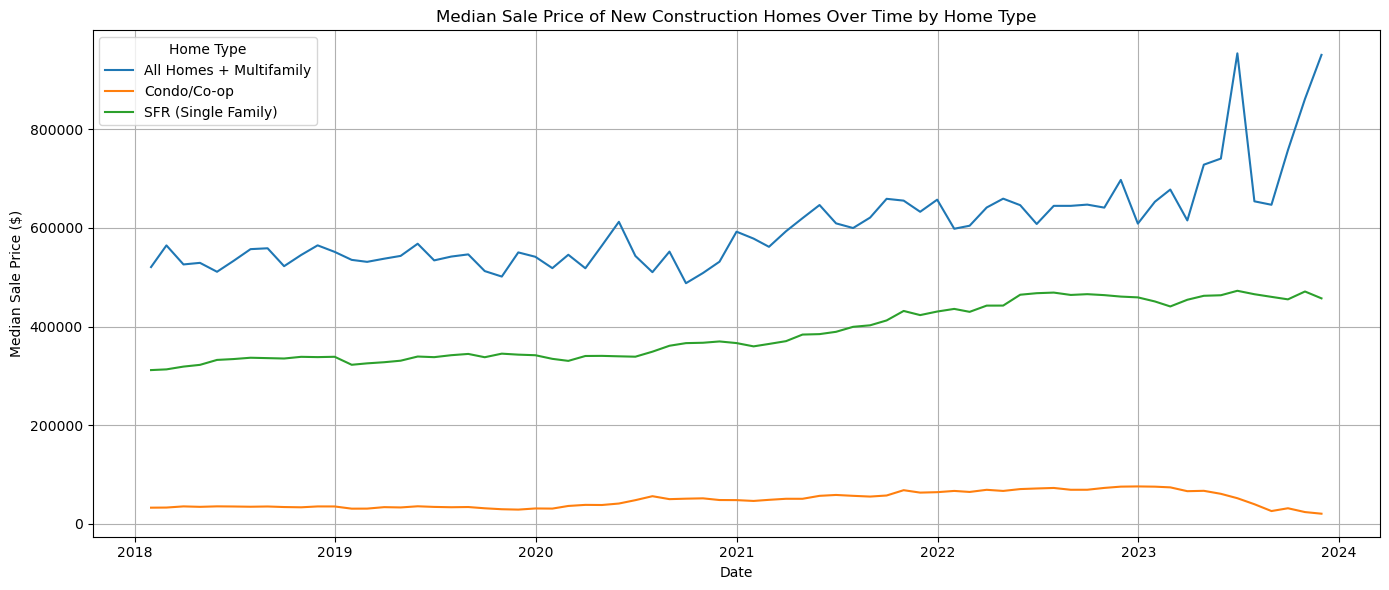

In [38]:
home_type_map = {
    0: 'All Homes',
    1: 'All Homes + Multifamily',
    2: 'SFR (Single Family)',
    3: 'Condo/Co-op',
    4: 'Multifamily'
}
dfnc_cleaned['Home Type Label'] = dfnc_cleaned['Home Type'].map(home_type_map)

price_trend = (
    dfnc_cleaned.groupby(['Date', 'Home Type Label'])['Median Sale Price']
    .mean()
    .reset_index()
)

plt.figure(figsize=(14, 6))
sns.lineplot(data=price_trend, x='Date', y='Median Sale Price', hue='Home Type Label')
plt.title('Median Sale Price of New Construction Homes Over Time by Home Type')
plt.xlabel('Date')
plt.ylabel('Median Sale Price ($)')
plt.legend(title='Home Type')
plt.grid(True)
plt.tight_layout()
plt.show()


/var/folders/pr/dq7r5k250_b6mj846ln15zsr0000gn/T/ipykernel_31276/2853291482.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfnc_cleaned['Period'] = dfnc_cleaned['Date'].apply(lambda x: 'Pre-COVID' if x < covid_start else 'Post-COVID')


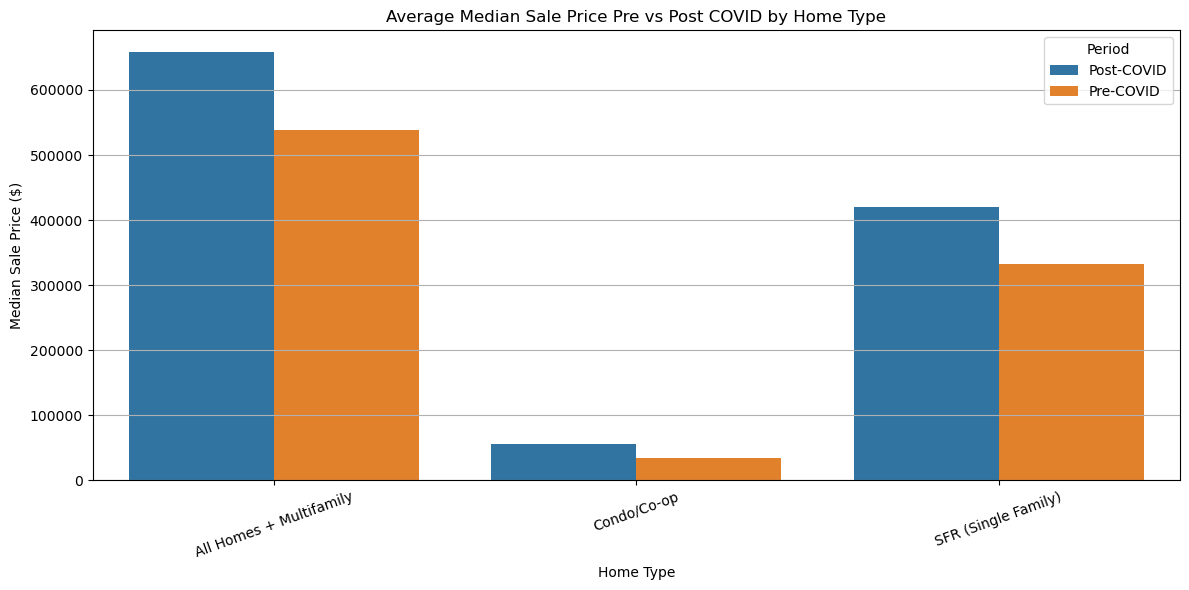

In [46]:
covid_start = pd.to_datetime('2020-03-01')

# Create a new column to classify periods
dfnc_cleaned['Period'] = dfnc_cleaned['Date'].apply(lambda x: 'Pre-COVID' if x < covid_start else 'Post-COVID')

# Group by Period and Home Type, compute average Median Sale Price
bar_data = (
    dfnc_cleaned.groupby(['Period', 'Home Type Label'])['Median Sale Price']
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 6))
sns.barplot(data=bar_data, x='Home Type Label', y='Median Sale Price', hue='Period')
plt.title('Average Median Sale Price Pre vs Post COVID by Home Type')
plt.xlabel('Home Type')
plt.ylabel('Median Sale Price ($)')
plt.xticks(rotation=20)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

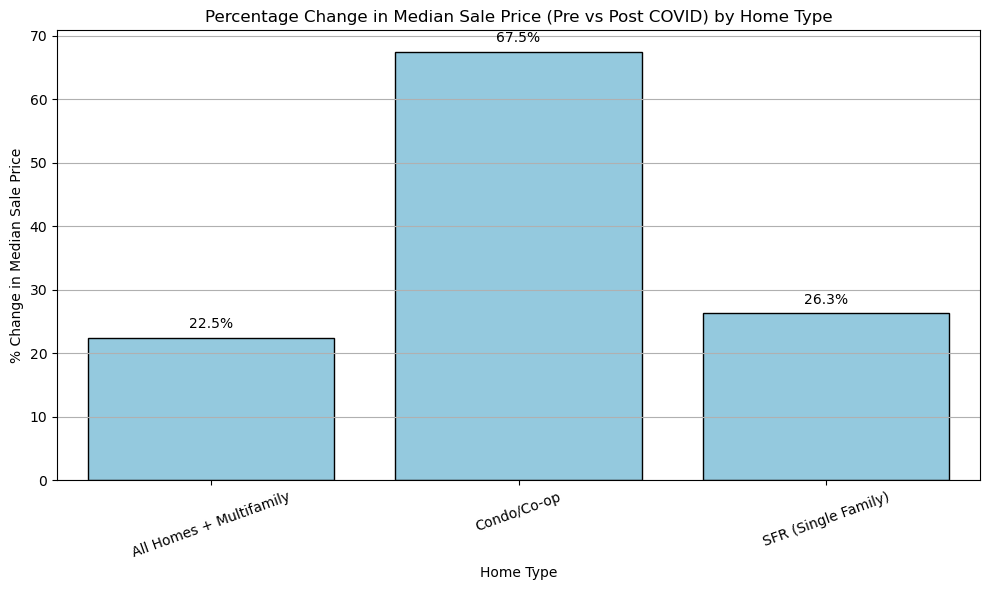

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convert Date column to datetime
dfnc['Date'] = pd.to_datetime(dfnc['Date'])

# COVID cutoff
covid_start = pd.to_datetime('2020-03-01')

# Classify each row as pre or post COVID
dfnc['Period'] = dfnc['Date'].apply(lambda x: 'Pre-COVID' if x < covid_start else 'Post-COVID')

# Map Home Type codes to readable labels
home_type_map = {
    0: 'All Homes',
    1: 'All Homes + Multifamily',
    2: 'SFR (Single Family)',
    3: 'Condo/Co-op',
    4: 'Multifamily'
}
dfnc['Home Type Label'] = dfnc['Home Type'].map(home_type_map)

# Calculate average median sale price per home type, per period
avg_prices = dfnc.groupby(['Period', 'Home Type Label'])['Median Sale Price'].mean().reset_index()

# Pivot the table to get pre and post COVID columns side by side
price_pivot = avg_prices.pivot(index='Home Type Label', columns='Period', values='Median Sale Price')
price_pivot['% Change'] = ((price_pivot['Post-COVID'] - price_pivot['Pre-COVID']) / price_pivot['Pre-COVID']) * 100
price_pivot = price_pivot.reset_index()

# Plot % change as bar chart with labels
plt.figure(figsize=(10, 6))
bar_plot = sns.barplot(data=price_pivot, x='Home Type Label', y='% Change', color='skyblue', edgecolor='black')

# Add % change labels on top of each bar
for index, row in price_pivot.iterrows():
    bar_plot.text(index, row['% Change'] + 1, f"{row['% Change']:.1f}%", 
                  ha='center', va='bottom', fontsize=10, color='black')

plt.title('Percentage Change in Median Sale Price (Pre vs Post COVID) by Home Type')
plt.ylabel('% Change in Median Sale Price')
plt.xlabel('Home Type')
plt.xticks(rotation=20)
plt.grid(axis='y')
plt.tight_layout()
plt.show()